# 💳 Credit Risk Assessment — Loan Default Prediction

Predict whether a loan applicant is **high-risk** (likely to default) or **low-risk**, comparing four classical ML models against a tuned neural network.

**Dataset:** [Credit Risk Dataset](https://www.kaggle.com/datasets/laotse/credit-risk-dataset) — 32,581 loan records, 11 features

### 📋 Pipeline
1. **Cleaning:** median-impute employment length, drop `loan_int_rate` (~10% missing), remove duplicates & outliers
2. **Feature engineering:** recompute `loan_percent_income`
3. **Encoding:** binary (default history), ordinal (loan grade A→G), one-hot (home ownership, loan intent)
4. **Split & scale:** stratified 80/20 split + `StandardScaler`
5. **Modeling:** Perceptron, Logistic Regression, SVM, Random Forest, Keras MLP
6. **Tuning:** layer sizes, activations, optimizers, batch sizes, with dropout + early stopping

### 🏆 Results (held-out test set, 6,453 applicants)

| Model | Accuracy |
|---|---|
| Perceptron | 80.2% |
| Logistic Regression | 86.1% |
| SVM (RBF) | 91.4% |
| **Random Forest (200 trees)** | **93.46%** |
| Neural Network (baseline, 32→16) | 92.6% |
| Neural Network (tuned, 64→32→Dropout→16) | 92.3% |

All seeds are fixed (`random_state=42` for scikit-learn, `set_random_seed(42)` + deterministic ops for TensorFlow), so re-running the notebook reproduces these numbers exactly.

The tuned network is deployed as an interactive **Streamlit** app → [GitHub repo](https://github.com/ZIADMAHMOUD0/credit-risk-assessment)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.decomposition import PCA
from sklearn.linear_model import Perceptron
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import itertools
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model

In [2]:
import tensorflow as tf

# Fix Python, NumPy and TensorFlow seeds so the neural-network results are identical on every run
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

In [3]:
import glob

# Works on Kaggle (dataset attached as input) and locally (CSV next to the notebook)
csv_path = (glob.glob('/kaggle/input/**/credit_risk_dataset.csv', recursive=True) or ['credit_risk_dataset.csv'])[0]
data = pd.read_csv(csv_path)

In [4]:
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
data.shape

(32581, 12)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


# Data Preprocessing

## Handle missing values

In [7]:
data.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
data['person_emp_length'] = data['person_emp_length'].fillna(data['person_emp_length'].median())

In [9]:
data = data.drop(['loan_int_rate'], axis=1)

In [10]:
data.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

## Handle duplicates

In [11]:
data = data.drop_duplicates()

## Handle outliers

In [12]:
data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32405.000000,3.240500e+04,32405.000000,32405.000000,32405.000000,32405.000000,32405.000000
mean,27.748125,6.609516e+04,4.769542,9594.201512,0.218732,0.170252,5.812344
std,6.354683,6.202414e+04,4.090647,6323.225445,0.413393,0.106820,4.059290
min,20.000000,4.000000e+03,0.000000,500.000000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,0.000000,0.150000,4.000000
75%,30.000000,7.938000e+04,7.000000,12250.000000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,1.000000,0.830000,30.000000


In [13]:
age_outliers = data[data['person_age'] > 100].shape[0]
income_outliers = data[data['person_income'] > 300000].shape[0]
emp_outliers = data[data['person_emp_length'] > 50].shape[0]

print("Outliers in person_age:", age_outliers)
print("Outliers in person_income:", income_outliers)
print("Outliers in person_emp_length:", emp_outliers)

Outliers in person_age: 5
Outliers in person_income: 137
Outliers in person_emp_length: 2


In [14]:
# Remove outliers for person_age > 100
data = data[data['person_age'] <= 100]

In [15]:
# Remove outliers for person_income > 300,000
data = data[data['person_income'] <= 300000]

In [16]:
# Remove outliers for employment length > 50 years
data = data[data['person_emp_length'] <= 50]

In [17]:
data['loan_percent_income'] = round(data['loan_amnt'] / data['person_income'], 2)

In [18]:
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,1,0.64,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,1,0.25,N,2


## Encode categorical variables

In [19]:
# 1) Binary Encoding
data['cb_person_default_on_file'] = data['cb_person_default_on_file'].map({'Y': 1, 'N': 0})

# 2) Ordinal Encoding for loan_grade (A < B < C < D < E < F < G)
grade_order = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7}
data['loan_grade'] = data['loan_grade'].map(grade_order)

# 3) One-Hot Encoding for nominal categorical columns
data = pd.get_dummies(data, columns=['person_home_ownership', 'loan_intent'], drop_first=True)

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32262 entries, 1 to 32580
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   32262 non-null  int64  
 1   person_income                32262 non-null  int64  
 2   person_emp_length            32262 non-null  float64
 3   loan_grade                   32262 non-null  int64  
 4   loan_amnt                    32262 non-null  int64  
 5   loan_status                  32262 non-null  int64  
 6   loan_percent_income          32262 non-null  float64
 7   cb_person_default_on_file    32262 non-null  int64  
 8   cb_person_cred_hist_length   32262 non-null  int64  
 9   person_home_ownership_OTHER  32262 non-null  bool   
 10  person_home_ownership_OWN    32262 non-null  bool   
 11  person_home_ownership_RENT   32262 non-null  bool   
 12  loan_intent_EDUCATION        32262 non-null  bool   
 13  loan_intent_HOMEIMPRO

## Correlation Heatmap

In [21]:
corr = data.corr()
corr

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
person_age,1.000000,0.105884,0.168414,0.011836,0.047268,-0.020252,-0.034158,0.004882,0.877468,-0.010570,-0.000884,-0.028279,-0.091963,0.076440,0.021514,0.033228,-0.013878
person_income,0.105884,1.000000,0.187866,-0.009116,0.405985,-0.220288,-0.341368,-0.013782,0.086829,0.003985,-0.063075,-0.267178,-0.010996,0.070971,-0.058342,0.004262,0.008141
person_emp_length,0.168414,0.187866,1.000000,-0.048068,0.110095,-0.085919,-0.054779,-0.030031,0.145559,-0.014341,0.023643,-0.231488,-0.037931,0.031869,-0.002091,0.008395,0.009987
loan_grade,0.011836,-0.009116,-0.048068,1.000000,0.145038,0.373752,0.129890,0.536554,0.013205,0.016947,-0.016856,0.120967,-0.008272,0.029141,0.001393,-0.006603,-0.010909
loan_amnt,0.047268,0.405985,0.110095,0.145038,1.000000,0.107214,0.587069,0.037996,0.038255,0.010806,-0.025823,-0.113765,-0.007918,0.042532,-0.024927,-0.001043,-0.000617
loan_status,-0.020252,-0.220288,-0.085919,0.373752,0.107214,1.000000,0.385999,0.179083,-0.014846,0.013475,-0.102303,0.238323,-0.055512,0.037078,0.055996,-0.021713,-0.078131
loan_percent_income,-0.034158,-0.341368,-0.054779,0.129890,0.587069,0.385999,1.000000,0.039792,-0.024417,0.012683,0.050041,0.113405,-0.003421,-0.016571,0.021330,-0.005327,-0.001300
cb_person_default_on_file,0.004882,-0.013782,-0.030031,0.536554,0.037996,0.179083,0.039792,1.000000,0.002470,0.013850,-0.003667,0.061921,-0.006196,0.015170,-0.003141,-0.003333,-0.003008
cb_person_cred_hist_length,0.877468,0.086829,0.145559,0.013205,0.038255,-0.014846,-0.024417,0.002470,1.000000,-0.008566,0.005076,-0.023606,-0.077728,0.058648,0.016799,0.034513,-0.008785
person_home_ownership_OTHER,-0.010570,0.003985,-0.014341,0.016947,0.010806,0.013475,0.012683,0.013850,-0.008566,1.000000,-0.016667,-0.057589,-0.006314,-0.000908,-0.003356,0.000549,0.009721


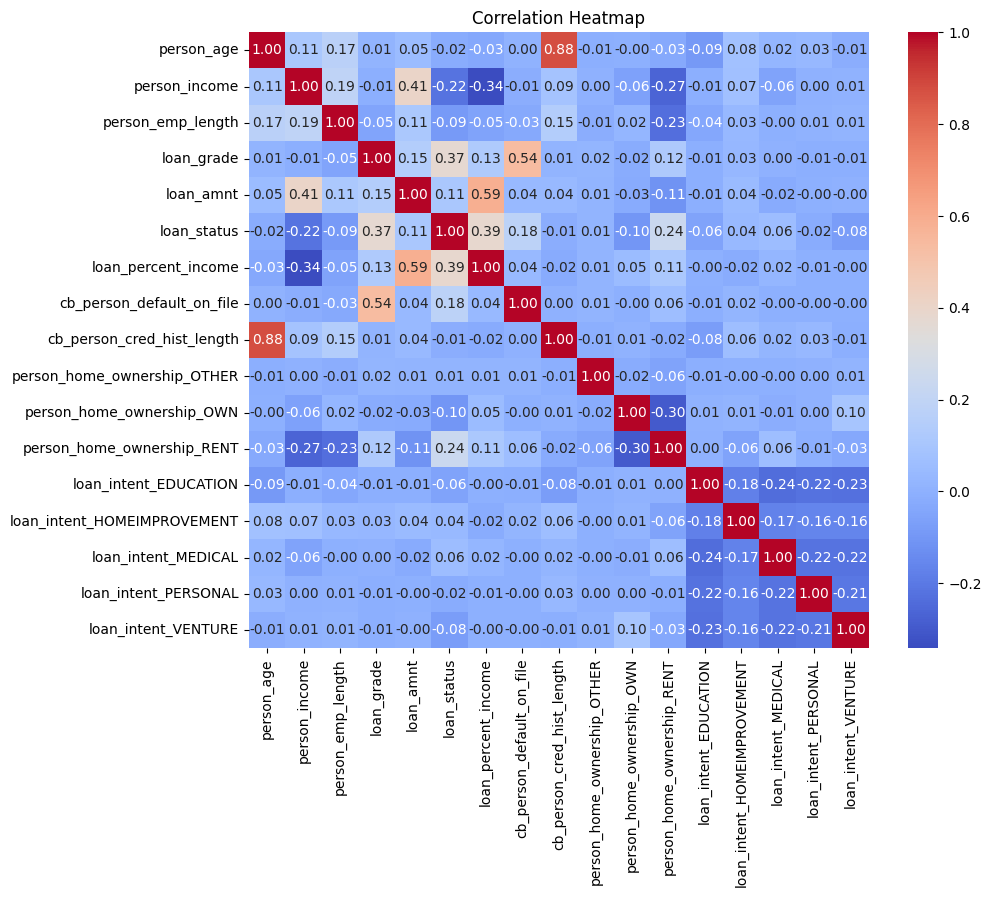

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## Split the dataset

In [23]:
x = data.drop(['loan_status'], axis=1)
y = data['loan_status']

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

## Scale numeric features

In [25]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 
                'loan_percent_income', 'cb_person_cred_hist_length']

In [26]:
scaler = StandardScaler()

x_train[numeric_cols] = scaler.fit_transform(x_train[numeric_cols])
x_test[numeric_cols] = scaler.transform(x_test[numeric_cols])

In [27]:
feature_columns = x_train.columns.tolist()

# Classical ML Models

## Perceptron (PLA)

In [28]:
pla = Perceptron(max_iter=1000, eta0=1.0, random_state=42)

pla.fit(x_train, y_train)

Perceptron(random_state=42)

In [29]:
y_pred = pla.predict(x_test)

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8021075468774214

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.85      0.87      5038
           1       0.54      0.63      0.58      1415

    accuracy                           0.80      6453
   macro avg       0.72      0.74      0.73      6453
weighted avg       0.81      0.80      0.81      6453



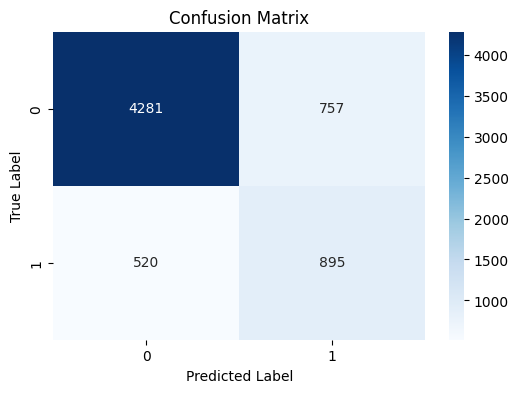

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [32]:
# Reduce to 2D for visualization
pca = PCA(n_components=2)
x_test_2d = pca.fit_transform(x_test)

# Grid for plotting
x_min, x_max = x_test_2d[:, 0].min() - 1, x_test_2d[:, 0].max() + 1
y_min, y_max = x_test_2d[:, 1].min() - 1, x_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict on grid
grid = np.c_[xx.ravel(), yy.ravel()]
# Transform back to original feature space
grid_orig = pca.inverse_transform(grid)

In [33]:
Z = (pla.predict(grid_orig) > 0.5).astype(int)
Z = Z.reshape(xx.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


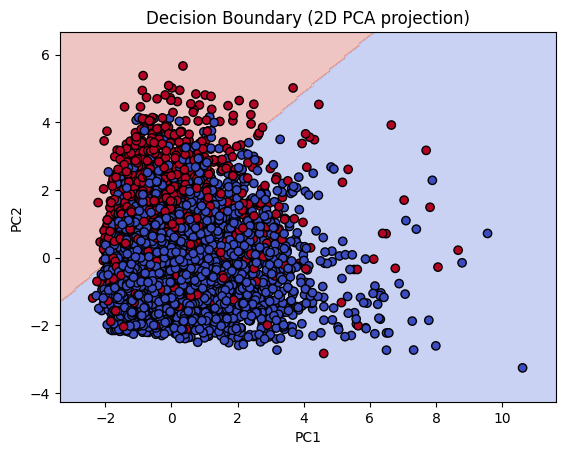

In [34]:
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(x_test_2d[:,0], x_test_2d[:,1], c=y_test, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Decision Boundary (2D PCA projection)')
plt.show()

## Logistic Regression

In [35]:
lg = LogisticRegression(max_iter=1000)
lg.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [36]:
y_pred = lg.predict(x_test)

In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.860684952735162

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91      5038
           1       0.75      0.55      0.63      1415

    accuracy                           0.86      6453
   macro avg       0.82      0.75      0.77      6453
weighted avg       0.85      0.86      0.85      6453



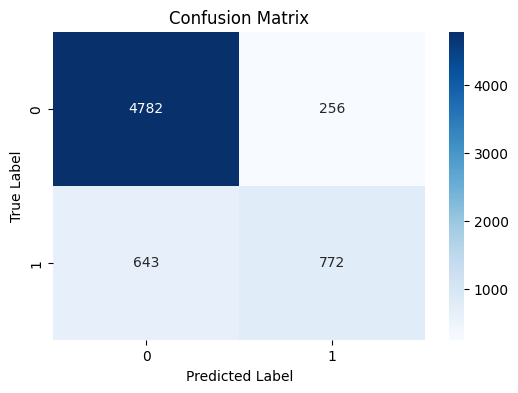

In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [39]:
Z = (lg.predict(grid_orig) > 0.5).astype(int)
Z = Z.reshape(xx.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


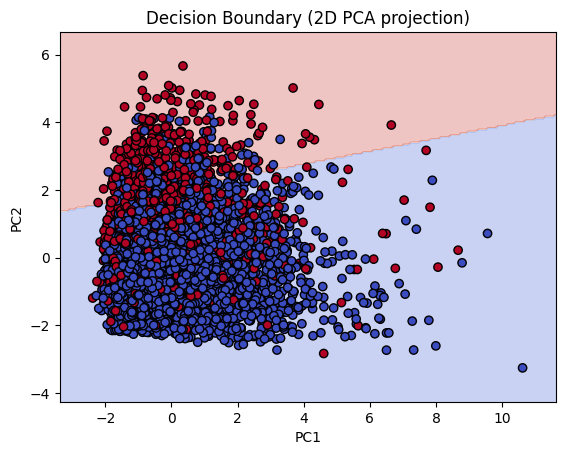

In [40]:
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(x_test_2d[:,0], x_test_2d[:,1], c=y_test, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Decision Boundary (2D PCA projection)')
plt.show()

## Support Vector Machine (SVM)

In [41]:
svm_model = SVC(kernel="rbf", C=1, gamma="scale")  
svm_model.fit(x_train, y_train)

SVC(C=1)

In [42]:
y_pred = svm_model.predict(x_test)

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9138385247171859

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95      5038
           1       0.93      0.66      0.77      1415

    accuracy                           0.91      6453
   macro avg       0.92      0.82      0.86      6453
weighted avg       0.92      0.91      0.91      6453



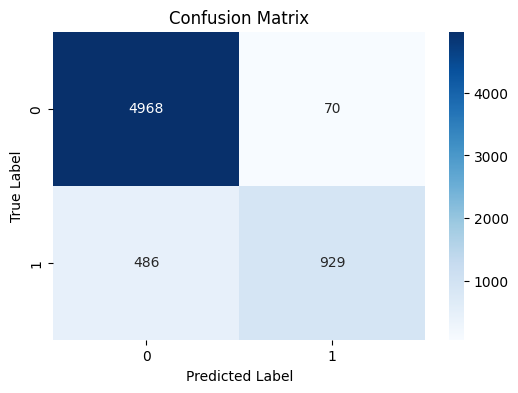

In [44]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [45]:
Z = (svm_model.predict(grid_orig) > 0.5).astype(int)
Z = Z.reshape(xx.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


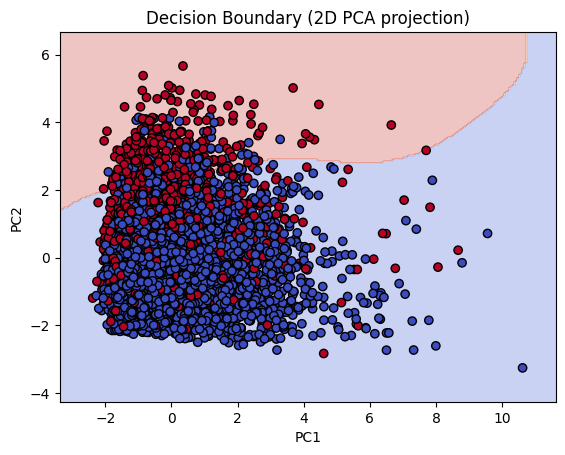

In [46]:
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(x_test_2d[:,0], x_test_2d[:,1], c=y_test, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Decision Boundary (2D PCA projection)')
plt.show()

## Random Forest

In [47]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf.fit(x_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [48]:
y_pred = rf.predict(x_test)

In [49]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9346040601270726

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      5038
           1       0.96      0.73      0.83      1415

    accuracy                           0.93      6453
   macro avg       0.94      0.86      0.90      6453
weighted avg       0.94      0.93      0.93      6453



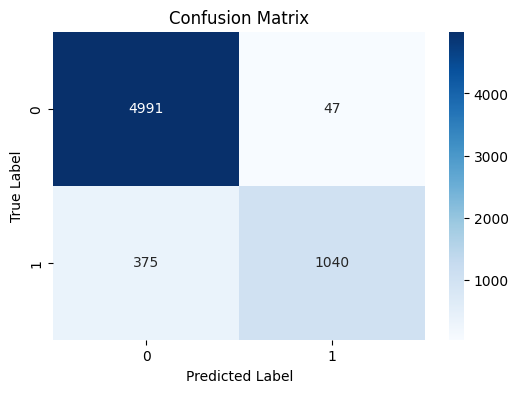

In [50]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [51]:
Z = (rf.predict(grid_orig) > 0.5).astype(int)
Z = Z.reshape(xx.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


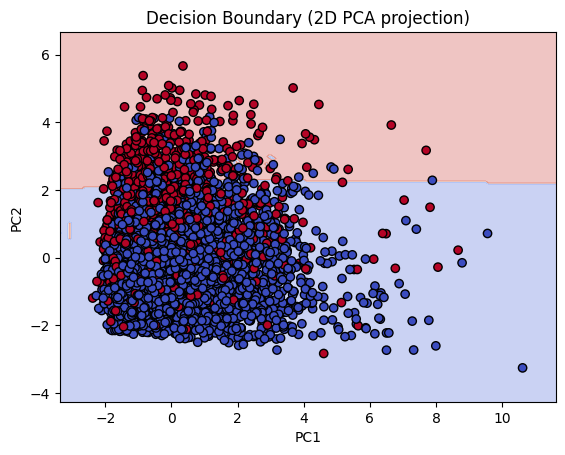

In [52]:
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(x_test_2d[:,0], x_test_2d[:,1], c=y_test, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Decision Boundary (2D PCA projection)')
plt.show()

# Neural Network Model

## Dense neural network (MLP)

In [53]:
nn_model = Sequential([
    Dense(32, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') 
])

nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
nn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-27 16:09:13.401420: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089 (4.25 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
# A fresh callback for each fit, so early-stopping state never leaks between models
def make_early_stop():
    return EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

In [55]:
history = nn_model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[make_early_stop()]  
)

Epoch 1/100


2026-09-27 16:09:13.605501: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


646/646 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8303 - loss: 0.4050 - val_accuracy: 0.8570 - val_loss: 0.3447
Epoch 2/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8762 - loss: 0.3185 - val_accuracy: 0.8816 - val_loss: 0.3141
Epoch 3/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8868 - loss: 0.2983 - val_accuracy: 0.8867 - val_loss: 0.3018
Epoch 4/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8924 - loss: 0.2889 - val_accuracy: 0.8896 - val_loss: 0.2954
Epoch 5/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8957 - loss: 0.2827 - val_accuracy: 0.8929 - val_loss: 0.2909
Epoch 6/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8993 - loss: 0.2776 - val_accuracy: 0.8946 - val_loss: 0.2871
Epoch 7/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9010 - loss: 0.2733 - val_accuracy: 0.8944 - val_loss: 0.2842
Epoch 8/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9031 - loss: 0.2694 - val_accuracy: 0.8958

In [56]:
y_pred = (nn_model.predict(x_test) > 0.5).astype('int32')
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)


101/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

2026-09-27 16:10:42.643716: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test Accuracy: 0.9256159925615992


## accuracy/loss curves

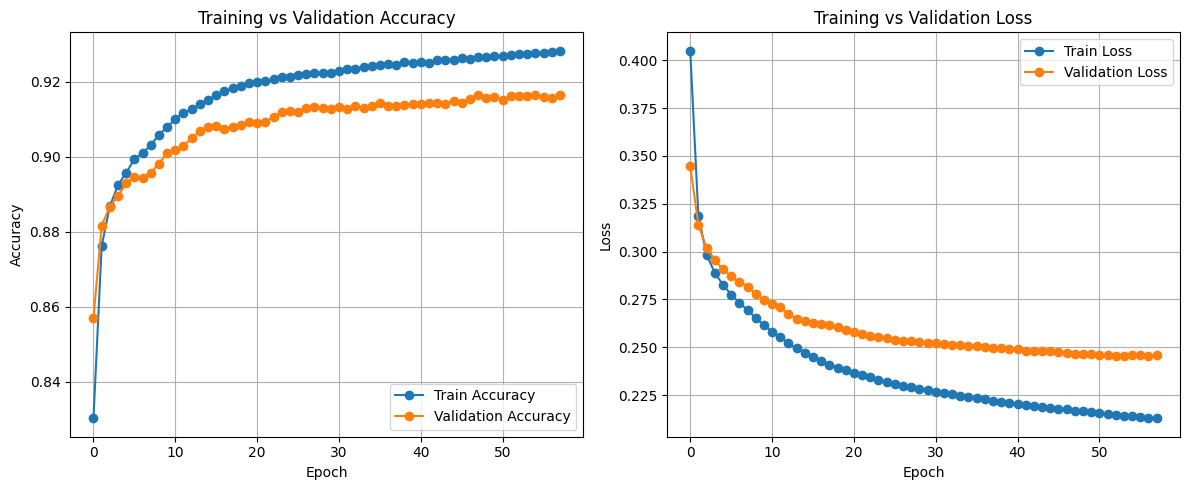

In [57]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss 
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Confusion matrix

202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


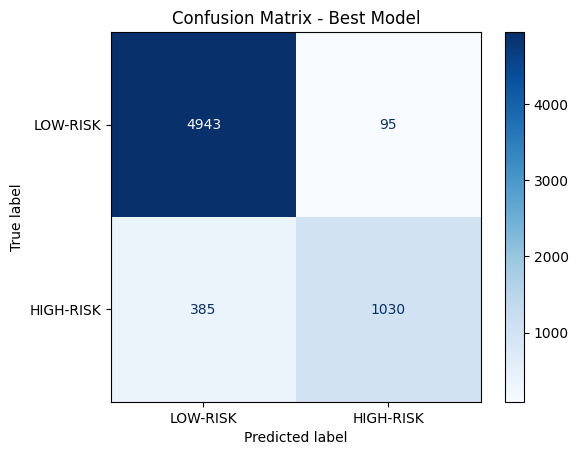

In [58]:
y_pred_prob = nn_model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int) 

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LOW-RISK', 'HIGH-RISK'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Best Model")
plt.show()

## Decision Boundary

In [59]:
Z = (nn_model.predict(grid_orig) > 0.5).astype(int)
Z = Z.reshape(xx.shape)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 877us/step


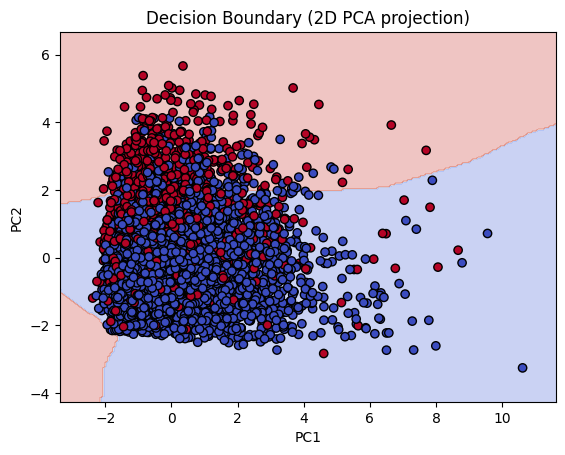

In [60]:
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(x_test_2d[:,0], x_test_2d[:,1], c=y_test, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Decision Boundary (2D PCA projection)')
plt.show()

# Hyperparameter Tuning

In [61]:
def create_model(layers=[32, 16], activation='relu', optimizer='adam'):
    model = Sequential()
    model.add(Dense(layers[0], activation=activation, input_shape=(x_train.shape[1],)))
    for neurons in layers[1:]:
        model.add(Dense(neurons, activation=activation))
    model.add(Dense(1, activation='sigmoid'))  
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [62]:
def train_and_update(model, description=""):
    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        verbose=1,
        callbacks=[make_early_stop()]  
    )
    val_acc = max(history.history['val_accuracy'])
    print(f"{description} → Validation Accuracy: {val_acc:.4f}")
    
    return history

## Try Different Numbers of Layers & Neurons

In [63]:
configs = [[32, 16], [64, 32, 16]]
for cfg in configs:
    model = create_model(layers=cfg)
    train_and_update(model, description=f"Layers {cfg}")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


640/646 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7586 - loss: 0.4978

2026-09-27 16:10:48.359238: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


646/646 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8222 - loss: 0.4127 - val_accuracy: 0.8615 - val_loss: 0.3418
Epoch 2/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8780 - loss: 0.3132 - val_accuracy: 0.8828 - val_loss: 0.3066
Epoch 3/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8897 - loss: 0.2939 - val_accuracy: 0.8900 - val_loss: 0.2974
Epoch 4/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8957 - loss: 0.2859 - val_accuracy: 0.8921 - val_loss: 0.2924
Epoch 5/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8985 - loss: 0.2806 - val_accuracy: 0.8929 - val_loss: 0.2891
Epoch 6/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9006 - loss: 0.2762 - val_accuracy: 0.8936 - val_loss: 0.2860
Epoch 7/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9031 - loss: 0.2723 - val_accuracy: 0.8946 - val_loss: 0.2826
Epoch 8/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9045 - loss: 0.2686 - val_accuracy: 0.8973

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-27 16:12:28.671472: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeD

646/646 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8439 - loss: 0.3808 - val_accuracy: 0.8696 - val_loss: 0.3264
Epoch 2/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8834 - loss: 0.2987 - val_accuracy: 0.8913 - val_loss: 0.2999
Epoch 3/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8956 - loss: 0.2784 - val_accuracy: 0.8954 - val_loss: 0.2877
Epoch 4/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9045 - loss: 0.2662 - val_accuracy: 0.9004 - val_loss: 0.2789
Epoch 5/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9088 - loss: 0.2578 - val_accuracy: 0.9000 - val_loss: 0.2768
Epoch 6/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9118 - loss: 0.2508 - val_accuracy: 0.9039 - val_loss: 0.2715
Epoch 7/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9151 - loss: 0.2447 - val_accuracy: 0.9072 - val_loss: 0.2669
Epoch 8/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9180 - loss: 0.2394 - val_accuracy: 0.9093

**so Layers [64, 32, 16] is better**

## Try Different Activation Functions

In [64]:
activations = ['relu', 'tanh', 'sigmoid']
for act in activations:
    model = create_model(activation=act)
    train_and_update(model, description=f"Activation {act}")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-27 16:13:04.572311: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeD

646/646 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8282 - loss: 0.4106 - val_accuracy: 0.8601 - val_loss: 0.3455
Epoch 2/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8717 - loss: 0.3237 - val_accuracy: 0.8783 - val_loss: 0.3179
Epoch 3/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8834 - loss: 0.3044 - val_accuracy: 0.8849 - val_loss: 0.3036
Epoch 4/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8903 - loss: 0.2920 - val_accuracy: 0.8931 - val_loss: 0.2942
Epoch 5/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8951 - loss: 0.2838 - val_accuracy: 0.8946 - val_loss: 0.2886
Epoch 6/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8987 - loss: 0.2785 - val_accuracy: 0.8971 - val_loss: 0.2849
Epoch 7/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9008 - loss: 0.2747 - val_accuracy: 0.8989 - val_loss: 0.2823
Epoch 8/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9026 - loss: 0.2716 - val_accuracy: 0.8989

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-27 16:14:21.905766: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeD

646/646 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8277 - loss: 0.3938 - val_accuracy: 0.8516 - val_loss: 0.3526
Epoch 2/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8676 - loss: 0.3319 - val_accuracy: 0.8694 - val_loss: 0.3290
Epoch 3/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8795 - loss: 0.3116 - val_accuracy: 0.8805 - val_loss: 0.3129
Epoch 4/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8875 - loss: 0.2981 - val_accuracy: 0.8871 - val_loss: 0.3029
Epoch 5/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8921 - loss: 0.2891 - val_accuracy: 0.8915 - val_loss: 0.2960
Epoch 6/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8958 - loss: 0.2825 - val_accuracy: 0.8940 - val_loss: 0.2909
Epoch 7/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8983 - loss: 0.2772 - val_accuracy: 0.8973 - val_loss: 0.2869
Epoch 8/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9000 - loss: 0.2728 - val_accuracy: 0.8993

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-27 16:15:52.850458: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeD

646/646 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8098 - loss: 0.4273 - val_accuracy: 0.8394 - val_loss: 0.3808
Epoch 2/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8528 - loss: 0.3610 - val_accuracy: 0.8441 - val_loss: 0.3683
Epoch 3/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8544 - loss: 0.3538 - val_accuracy: 0.8446 - val_loss: 0.3642
Epoch 4/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8549 - loss: 0.3507 - val_accuracy: 0.8446 - val_loss: 0.3619
Epoch 5/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8560 - loss: 0.3486 - val_accuracy: 0.8456 - val_loss: 0.3602
Epoch 6/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8562 - loss: 0.3471 - val_accuracy: 0.8464 - val_loss: 0.3587
Epoch 7/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8574 - loss: 0.3455 - val_accuracy: 0.8475 - val_loss: 0.3569
Epoch 8/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8588 - loss: 0.3431 - val_accuracy: 0.8499

**so Activation relu is the best**

## Try Different Optimizers and Learning Rates

In [65]:
optimizers = [
    Adam(learning_rate=0.001),
    RMSprop(learning_rate=0.001),
    SGD(learning_rate=0.01)
]
for opt in optimizers:
    model = create_model(optimizer=opt)
    train_and_update(model, description=f"Optimizer {opt.get_config()['name']}")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-27 16:18:28.239511: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeD

646/646 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8200 - loss: 0.4144 - val_accuracy: 0.8472 - val_loss: 0.3598
Epoch 2/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8665 - loss: 0.3296 - val_accuracy: 0.8733 - val_loss: 0.3240
Epoch 3/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8824 - loss: 0.3047 - val_accuracy: 0.8882 - val_loss: 0.3062
Epoch 4/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8914 - loss: 0.2904 - val_accuracy: 0.8929 - val_loss: 0.2953
Epoch 5/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8963 - loss: 0.2819 - val_accuracy: 0.8938 - val_loss: 0.2896
Epoch 6/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9007 - loss: 0.2760 - val_accuracy: 0.8973 - val_loss: 0.2845
Epoch 7/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9043 - loss: 0.2712 - val_accuracy: 0.9004 - val_loss: 0.2815
Epoch 8/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9064 - loss: 0.2671 - val_accuracy: 0.9010

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-27 16:19:52.464517: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeD

646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8251 - loss: 0.4161 - val_accuracy: 0.8499 - val_loss: 0.3621
Epoch 2/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8668 - loss: 0.3345 - val_accuracy: 0.8679 - val_loss: 0.3331
Epoch 3/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8789 - loss: 0.3120 - val_accuracy: 0.8789 - val_loss: 0.3180
Epoch 4/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8872 - loss: 0.2982 - val_accuracy: 0.8849 - val_loss: 0.3071
Epoch 5/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8933 - loss: 0.2890 - val_accuracy: 0.8907 - val_loss: 0.2992
Epoch 6/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8951 - loss: 0.2826 - val_accuracy: 0.8927 - val_loss: 0.2940
Epoch 7/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8977 - loss: 0.2779 - val_accuracy: 0.8964 - val_loss: 0.2900
Epoch 8/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8998 - loss: 0.2746 - val_accuracy: 0.8964

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-27 16:21:24.882623: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeD

646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7713 - loss: 0.5182 - val_accuracy: 0.8229 - val_loss: 0.4327
Epoch 2/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8427 - loss: 0.3893 - val_accuracy: 0.8435 - val_loss: 0.3799
Epoch 3/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8577 - loss: 0.3552 - val_accuracy: 0.8578 - val_loss: 0.3560
Epoch 4/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8674 - loss: 0.3380 - val_accuracy: 0.8642 - val_loss: 0.3422
Epoch 5/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8731 - loss: 0.3277 - val_accuracy: 0.8669 - val_loss: 0.3343
Epoch 6/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8771 - loss: 0.3210 - val_accuracy: 0.8692 - val_loss: 0.3294
Epoch 7/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8796 - loss: 0.3163 - val_accuracy: 0.8723 - val_loss: 0.3255
Epoch 8/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8817 - loss: 0.3125 - val_accuracy: 0.8750

**so Optimizer adam is best**

## Try Different Batch Sizes

In [66]:
batch_sizes = [16, 32, 64]
for bs in batch_sizes:
    model = create_model()
    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=bs,
        verbose=1,
        callbacks=[make_early_stop()]
    )
    val_acc = max(history.history['val_accuracy'])
    print(f"Batch Size {bs} → Validation Accuracy: {val_acc:.4f}")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-27 16:23:50.085120: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeD

1291/1291 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8476 - loss: 0.3705 - val_accuracy: 0.8719 - val_loss: 0.3225
Epoch 2/100
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8872 - loss: 0.3010 - val_accuracy: 0.8880 - val_loss: 0.3023
Epoch 3/100
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8933 - loss: 0.2873 - val_accuracy: 0.8927 - val_loss: 0.2949
Epoch 4/100
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8984 - loss: 0.2789 - val_accuracy: 0.8967 - val_loss: 0.2889
Epoch 5/100
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9021 - loss: 0.2725 - val_accuracy: 0.8998 - val_loss: 0.2842
Epoch 6/100
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9050 - loss: 0.2673 - val_accuracy: 0.8997 - val_loss: 0.2803
Epoch 7/100
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9069 - loss: 0.2630 - val_accuracy: 0.9016 - val_loss: 0.2784
Epoch 8/100
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9089 - loss: 0.2595 - val_

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-27 16:26:03.953709: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeD

646/646 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8116 - loss: 0.4266 - val_accuracy: 0.8444 - val_loss: 0.3681
Epoch 2/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8647 - loss: 0.3340 - val_accuracy: 0.8694 - val_loss: 0.3284
Epoch 3/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8819 - loss: 0.3048 - val_accuracy: 0.8873 - val_loss: 0.3089
Epoch 4/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8911 - loss: 0.2903 - val_accuracy: 0.8911 - val_loss: 0.2996
Epoch 5/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8963 - loss: 0.2818 - val_accuracy: 0.8952 - val_loss: 0.2932
Epoch 6/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8994 - loss: 0.2756 - val_accuracy: 0.8979 - val_loss: 0.2882
Epoch 7/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9021 - loss: 0.2709 - val_accuracy: 0.9000 - val_loss: 0.2848
Epoch 8/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9045 - loss: 0.2670 - val_accuracy: 0.9016

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-27 16:27:47.342973: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeD

323/323 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8265 - loss: 0.4313 - val_accuracy: 0.8454 - val_loss: 0.3651
Epoch 2/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8637 - loss: 0.3399 - val_accuracy: 0.8675 - val_loss: 0.3312
Epoch 3/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8751 - loss: 0.3147 - val_accuracy: 0.8801 - val_loss: 0.3135
Epoch 4/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8853 - loss: 0.3001 - val_accuracy: 0.8840 - val_loss: 0.3041
Epoch 5/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8895 - loss: 0.2911 - val_accuracy: 0.8865 - val_loss: 0.2978
Epoch 6/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8940 - loss: 0.2847 - val_accuracy: 0.8902 - val_loss: 0.2927
Epoch 7/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8965 - loss: 0.2799 - val_accuracy: 0.8925 - val_loss: 0.2896
Epoch 8/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8989 - loss: 0.2760 - val_accuracy: 0.8944

**so Batch Size 32 is best**

# Train best model with best parameters

In [67]:
best_model = Sequential([
    Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(16, activation='relu'),
    
    Dense(1, activation='sigmoid') 
])

best_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = best_model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[make_early_stop()]  
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-27 16:28:50.994411: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeD

646/646 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8220 - loss: 0.4116 - val_accuracy: 0.8619 - val_loss: 0.3425
Epoch 2/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8683 - loss: 0.3321 - val_accuracy: 0.8876 - val_loss: 0.3011
Epoch 3/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8855 - loss: 0.3004 - val_accuracy: 0.8967 - val_loss: 0.2844
Epoch 4/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8910 - loss: 0.2889 - val_accuracy: 0.8991 - val_loss: 0.2786
Epoch 5/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8991 - loss: 0.2769 - val_accuracy: 0.9039 - val_loss: 0.2747
Epoch 6/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9021 - loss: 0.2707 - val_accuracy: 0.9060 - val_loss: 0.2689
Epoch 7/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9066 - loss: 0.2643 - val_accuracy: 0.9086 - val_loss: 0.2648
Epoch 8/100
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9086 - loss: 0.2605 - val_accuracy: 0.9066

In [68]:
y_pred = (best_model.predict(x_test) > 0.5).astype('int32')
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

 97/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

2026-09-27 16:29:23.588250: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test Accuracy: 0.9232914923291492


## Training and validation loss/accuracy curves

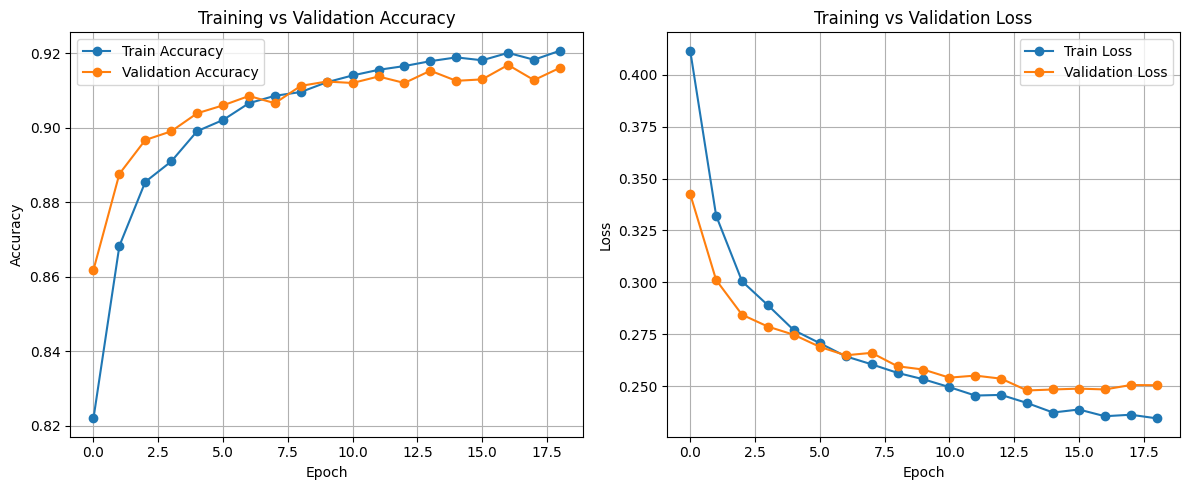

In [69]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss 
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Decision Boundary

In [70]:
Z = (best_model.predict(grid_orig) > 0.5).astype(int)
Z = Z.reshape(xx.shape)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 886us/step


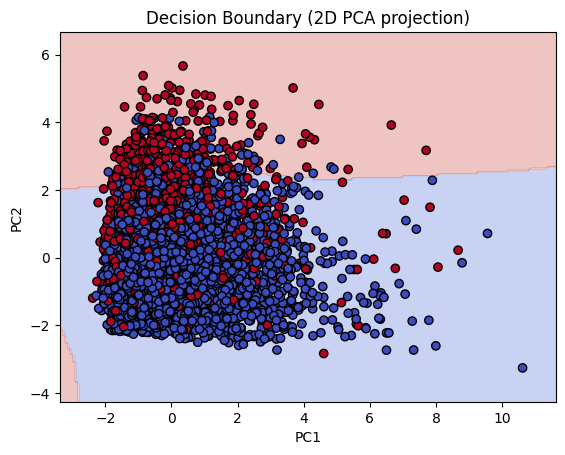

In [71]:
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(x_test_2d[:,0], x_test_2d[:,1], c=y_test, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Decision Boundary (2D PCA projection)')
plt.show()

## Confusion matrix

202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

    LOW-RISK     0.9207    0.9867    0.9526      5038
   HIGH-RISK     0.9364    0.6975    0.7995      1415

    accuracy                         0.9233      6453
   macro avg     0.9286    0.8421    0.8760      6453
weighted avg     0.9242    0.9233    0.9190      6453



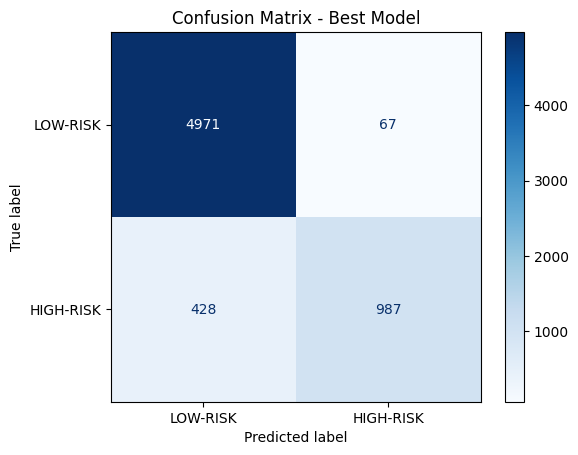

In [72]:
y_pred_prob = best_model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to 0/1

cm = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred, target_names=['LOW-RISK', 'HIGH-RISK'], digits=4))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LOW-RISK', 'HIGH-RISK'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Best Model")
plt.show()

# Save Best model

In [73]:
best_model.save('best_model.h5')
model = load_model('best_model.h5')

# Prediction on Unseen Data

## 5 new hypothetical customers

In [74]:
new_customers = pd.DataFrame([
    {
        "person_age": 22,
        "person_income": 59000,
        "person_home_ownership": "RENT",
        "person_emp_length": 123.0,
        "loan_intent": "PERSONAL",
        "loan_grade": "B",
        "loan_amnt": 15000,
        "loan_int_rate": 9.5,
        "loan_percent_income": 0.25,
        "cb_person_default_on_file": "N",
        "cb_person_cred_hist_length": 5
    },
    {
        "person_age": 45,
        "person_income": 120000,
        "person_home_ownership": "MORTGAGE",
        "person_emp_length": 240.0,
        "loan_intent": "EDUCATION",
        "loan_grade": "A",
        "loan_amnt": 10000,
        "loan_int_rate": 7.2,
        "loan_percent_income": 0.08,
        "cb_person_default_on_file": "N",
        "cb_person_cred_hist_length": 15
    },
    {
        "person_age": 28,
        "person_income": 48000,
        "person_home_ownership": "RENT",
        "person_emp_length": 15.0,
        "loan_intent": "PERSONAL",
        "loan_grade": "C",
        "loan_amnt": 8000,
        "loan_int_rate": 7.1,
        "loan_percent_income": 0.16,
        "cb_person_default_on_file": "N",
        "cb_person_cred_hist_length": 2
    },
    {
        "person_age": 52,
        "person_income": 98000,
        "person_home_ownership": "RENT",
        "person_emp_length": 140.0,
        "loan_intent": "VENTURE",
        "loan_grade": "E",
        "loan_amnt": 40000,
        "loan_int_rate": 18.2,
        "loan_percent_income": 0.41,
        "cb_person_default_on_file": "Y",
        "cb_person_cred_hist_length": 9
    },
    {
        "person_age": 31,
        "person_income": 75000,
        "person_home_ownership": "OWN",
        "person_emp_length": 60.0,
        "loan_intent": "MEDICAL",
        "loan_grade": "D",
        "loan_amnt": 25000,
        "loan_int_rate": 16.5,
        "loan_percent_income": 0.33,
        "cb_person_default_on_file": "Y",
        "cb_person_cred_hist_length": 6
    },
    {
        "person_age": 40,
        "person_income": 55000,
        "person_home_ownership": "RENT",
        "person_emp_length": 30.0,
        "loan_intent": "PERSONAL",
        "loan_grade": "E",
        "loan_amnt": 30000,
        "loan_int_rate": 17.0,
        "loan_percent_income": 0.55,
        "cb_person_default_on_file": "Y",
        "cb_person_cred_hist_length": 4
    }
])


## Apply same preprocessing

In [75]:
grade_order = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7}

new_customers['cb_person_default_on_file'] = new_customers['cb_person_default_on_file'].map({'Y':1, 'N':0})
new_customers['loan_grade'] = new_customers['loan_grade'].map(grade_order)
new_customers = pd.get_dummies(new_customers, columns=['person_home_ownership', 'loan_intent'], drop_first=True)

new_customers = new_customers.reindex(columns=feature_columns, fill_value=0)

new_customers[numeric_cols] = scaler.transform(new_customers[numeric_cols])

## Predict with the best model

In [76]:
probabilities = best_model.predict(new_customers)
predictions = (probabilities > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [77]:
for i, (prob, pred) in enumerate(zip(probabilities, predictions)):
    risk = "HIGH-RISK" if pred == 1 else "LOW-RISK"
    print(f"Customer {i+1}:  Probability={prob[0]:.4f} → {risk}")


Customer 1:  Probability=1.0000 → HIGH-RISK
Customer 2:  Probability=0.9476 → HIGH-RISK
Customer 3:  Probability=0.1563 → LOW-RISK
Customer 4:  Probability=0.9489 → HIGH-RISK
Customer 5:  Probability=0.2682 → LOW-RISK
Customer 6:  Probability=1.0000 → HIGH-RISK


---
## ✅ Conclusion

- **Random Forest** gave the best test accuracy (**93.46%**), with the neural networks and SVM close behind; the linear models trailed, which suggests non-linear feature interactions matter here.
- Hyperparameter tuning (layers, activations, optimizers, batch sizes, dropout) was selected on **validation** accuracy, and on the held-out test set the tuned network (**92.3%**) did not beat the simpler baseline (**92.6%**). An honest result: on this dataset, extra capacity doesn't buy accuracy.
- The tuned network reaches **93.6% precision** on high-risk applicants but **69.8% recall**, so about 3 in 10 defaulters are still missed. In lending, that recall gap is the next thing to improve (class weighting, threshold tuning).
- The saved model, scaler and feature columns power a Streamlit app for real-time predictions.

If you found this useful, an upvote is appreciated 🙌 — feedback welcome in the comments!